In [52]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from glob import glob
import rasterio as rio
from rasterio.mask import mask
from rasterio.io import MemoryFile
from rasterio.plot import show
from PIL import Image
import json
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from threading import Lock
from time import sleep
from src.mslandcover.config import MSTM_PROJ4, LEGEND_CLASSES
from src.mslandcover.utils import raise_if_not_exists
from src.mslandcover.data.preprocessing import extract_mask, extract_masks_from_raster
import cv2 as cv
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
from typing import Optional
from contextlib import nullcontext


from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from os import cpu_count

KeyboardInterrupt: 

In [ ]:
# load the shapefilse with boundaries of the regions
shapefiles = glob(r'Z:\\guser\\dh\\NAIP_MS_2023\\*\\*.shp')
gdfs = []
for shapefile in shapefiles:
    gdf = gpd.read_file(shapefile).to_crs(MSTM_PROJ4) # convert to the same projection
    raster_path = glob(os.path.join(os.path.dirname(shapefile), '*_1m.tif'))[0]
    gdf['raster_path'] = raster_path
    gdfs.append(gdf)

raster_boundaries_gdf = gpd.GeoDataFrame(pd.concat(gdfs))[['raster_path', 'geometry']] # only keep the relevant columns
raster_boundaries_gdf = raster_boundaries_gdf.dissolve(by='raster_path').reset_index() # dissolve the geometries to get the boundaries of the raster
raster_boundaries_gdf.to_file('data/sampling/regions_boundaries.gpkg', driver='GPKG')

In [ ]:
# load the samples parquet
raster_boundaries_gdf = gpd.read_file('data/sampling/regions_boundaries.gpkg')
samples = gpd.read_parquet('./data/sampling/samples.par')

# spatial join with the raster boundaries
raster_boundaries_gdf['raster_geometry'] = raster_boundaries_gdf['geometry'] # make a copy of the geometry
samples = gpd.sjoin(samples, raster_boundaries_gdf, predicate='intersects', how='left')

In [ ]:

# sample the train, test, and val splits
if False:
    n_threads = 8
    sub_samples = samples[samples['split'].isin(['train', 'test', 'val'])]
    pbar = tqdm(total=len(sub_samples), desc='Sampling train, test, and val splits splits', unit='samples')
    with ThreadPoolExecutor(max_workers=n_threads) as executor:
            list(
                executor.map(
                    lambda x: extract_masks_from_raster(x, lock=lock, pbar=pbar),
                    list(sub_samples.groupby('raster_path'))
                )
            )

# sample the pretrain and pretrain_val splits
if True:
    n_threads = 8
    lock = Lock()
    sub_samples = samples[samples['split'].isin(['pretrain', 'pretrain_val'])]
    pbar = tqdm(total=len(sub_samples), desc='Sampling pretrain and pretrain_val splits', unit='samples')
    with ThreadPoolExecutor(max_workers=n_threads) as executor:
        list(
            executor.map(
                lambda x: extract_masks_from_raster(x, lock=lock, pbar=pbar),
                list(sub_samples.groupby('raster_path'))
            )
        )


Sampling pretrain and pretrain_val splits:  16%|█▌        | 110296/688353 [56:38<4:33:21, 35.24samples/s]

type(Input shapes do not overlap raster.) raised while extracting mask for sample 1669908 in split pretrain: Input shapes do not overlap raster.


Sampling pretrain and pretrain_val splits:  16%|█▋        | 112367/688353 [57:39<4:37:53, 34.54samples/s]

type(Input shapes do not overlap raster.) raised while extracting mask for sample 1669946 in split pretrain: Input shapes do not overlap raster.


Sampling pretrain and pretrain_val splits:  17%|█▋        | 114450/688353 [58:41<4:37:37, 34.45samples/s]

...

type(Input shapes do not overlap raster.) raised while extracting mask for sample 2448408 in split pretrain: Input shapes do not overlap raster.


Sampling pretrain and pretrain_val splits:  94%|█████████▍| 646043/688353 [5:30:19<29:27, 23.94samples/s]

type(Input shapes do not overlap raster.) raised while extracting mask for sample 2454684 in split pretrain_val: Input shapes do not overlap raster.


Sampling pretrain and pretrain_val splits:  95%|█████████▍| 651179/688353 [5:36:53<42:02, 14.73samples/s]  

Sampling pretrain and pretrain_val splits:  95%|█████████▍| 651180/688353 [5:37:11<42:02, 14.73samples/s]

In [ ]:
# sample pretrain and pretrain_val splits


Hello


In [ ]:
sampled_files = glob('data/splits/*/*.tif')
sampled_files.extend(glob('data/splits/*/*/*.tif'))
sampled_ids = [int(os.path.basename(file).replace('.tif', '')) for file in sampled_files]
remaining_samples = samples[~samples.index.isin(sampled_ids)]

display(remaining_samples.groupby('split').count())

,geometry,hist_vector,hist_vector_scaled,hist_vector_pca,cluster,index_right,raster_path,raster_geometry
split,,,,,,,,
pretrain,8,8,8,8,8,7,7,7


In [ ]:


# convert samples in train, test, val splits to png for annotation
for split in ['train', 'test', 'val']:
    
    os.makedirs(os.path.join('data', 'roboflow', split, 'input'), exist_ok=True)
    os.makedirs(os.path.join('data', 'roboflow', split, 'target'), exist_ok=True)
    samples_split = samples[samples['split'] == split]
    
    sample_files = glob(f'data/splits/{split}/input/*.tif')
    sample_ids = [int(os.path.basename(file).replace('.tif', '')) for file in sample_files]
    
    for id, file in zip(sample_ids, sample_files):
        with rio.open(file) as src:
            img = Image.fromarray(src.read().transpose(1, 2, 0))
            meta = src.meta
        
        # add lat, long of the centroid of the sample to the metadata
        sample = samples_split.loc[id]
        if type(sample) == gpd.GeoDataFrame:
            sample = sample.iloc[0]
        centroid = sample['geometry'].centroid
        meta['lat'] = centroid.y
        meta['lon'] = centroid.x
        
        # from histogram vector, add the relative frequency of each class to the metadata
        hist = sample['hist_vector']
        legend_classes = LEGEND_CLASSES.copy()
        legend_classes.pop(0) # remove nodata class
        
        meta['class_freq'] = {legend_classes[i+1]: hist[i] for i in range(len(hist))}

        # need to convert CRS to string such that it is serializable
        meta['crs'] = meta['crs'].to_string()
        
        with open(f'data/png_images/{split}/input/{id}.json', 'w') as f:
            json.dump(meta, f, indent=4)
        
        img.save(f'data/png_images/{split}/input/{id}.png')

<!-- ## Sampling Points for Accuracy Assesment -->

In [ ]:
# sample 10,000 images from CPN

cpb_lc_path = './'
naip_image_path = './data/'

In [1]:

import pystac_client
import planetary_computer
import geopandas as gpd
import pyproj
from shapely import to_geojson, from_geojson
from shapely.ops import transform
import rioxarray as rxr
import xarray as xr
from src.mslandcover.config import MSTM_PROJ4
import os
from time import sleep
import numpy as np
from rasterio.enums import Resampling
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm
from dask.distributed import Client


# dask_client = Client(n_workers=24, memory_limit='2GB')

In [2]:

samples_gdf = gpd.read_parquet('./data/sampling/samples.par')
class MSTM2WGS84_Transformer:
    def __init__(self):
        self.transformer = pyproj.Transformer.from_proj(
            pyproj.Proj(MSTM_PROJ4),
            pyproj.Proj(4326),
            always_xy=True
        )
    
    def transform(self, polygon_mstm):
        return transform(
            self.transformer.transform,
            polygon_mstm
        )
    
    def inv_transform(self, polygon_wgs84):
        return transform(
            self.transformer.inv_transform,
            polygon_wgs84
        )


transformer = MSTM2WGS84_Transformer()
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)


In [3]:
def download_image(series, transformer=transformer, base_path=os.path.join('/', 'scratch', 'dhester', 'mslc_data_v2')):
    
    if series['split'] in ['train', 'test', 'val']:
        out_path = os.path.join(base_path, series['split'], 'input', f'{str(series.name).zfill(7)}.tif')
    else:
        out_path = os.path.join(base_path, series['split'], f'{str(series.name).zfill(7)}.tif')
    if os.path.exists(out_path):
        # return
        pass
    
    geom_84 = transformer.transform(series.geometry)
    aoi = to_geojson(geom_84)
    
    max_attempts = 10
    for attempt in range(max_attempts):
        try:
            items = catalog.search(
                collections=['naip'],
                intersects=aoi,
                datetime='2023-01-01/2023-12-31',
            )
            items = list(items.items())
            break
        except Exception as e:
            sleep(5)
            continue
        finally:
            if attempt == max_attempts - 1:
                print(f'Failed to download image for {series.name} after {max_attempts} attempts')
                return
            
    if len(items) == 0:
        print(f'No items found for {series.name}')
        return

    # filter items by the ones that contain the geom entirely
    items = [item for item in items if from_geojson(item.geometry.__str__().replace("'", '"')).contains(geom_84)]
    if len(items) == 0:
        print(f'No items found for {series.name} - no containing items')
        return
    
    image = None
    for item in items:
        try:
            image = rxr.open_rasterio(item.assets['image'].href).rio.clip_box(
                *series.geometry.bounds,
                crs=samples_gdf.crs,
            ).rio.reproject(
                samples_gdf.crs,
                resolution=(1.0, 1.0),
            ).rio.clip([series.geometry])
            
        except rxr.exceptions.NoDataInBounds:
            continue

        if image.shape != (4, 256, 256):
            continue

        if (image == image.rio.nodata).all(dim=['band']).any():
            continue
        break
    
    if image is None:
        print(f'No valid image found for {series.name}')
        return
    
    return
    # os.makedirs(os.path.dirname(out_path), exist_ok=True)
    # image.rio.to_raster(out_path, driver='GTiff', dtype='uint8', compress='lzw')

test_series = samples_gdf.iloc[1]
image = download_image(test_series, transformer=transformer, base_path=os.path.join('/', 'scratch', 'dhester', 'mslc_data_v2'))

KeyboardInterrupt: 

In [4]:
def get_cog_url(series, transformer=transformer, base_path=os.path.join('/', 'scratch', 'dhester', 'mslc_data_v2')):
    
    
    if series['split'] in ['train', 'test', 'val']:
        out_path = os.path.join(base_path, series['split'], 'input', f'{str(series.name).zfill(7)}.tif')
    else:
        out_path = os.path.join(base_path, series['split'], f'{str(series.name).zfill(7)}.tif')
    if os.path.exists(out_path):
        # return
        pass
    
    geom_84 = transformer.transform(series.geometry)
    aoi = to_geojson(geom_84)
    
    max_attempts = 10
    for attempt in range(max_attempts):
        try:
            items = catalog.search(
                collections=['naip'],
                intersects=aoi,
                datetime='2023-01-01/2023-12-31',
            )
            items = list(items.items())
            break
        except Exception as e:
            sleep(5)
            continue
        finally:
            if attempt == max_attempts - 1:
                print(f'Failed to download image for {series.name} after {max_attempts} attempts')
                return
            
    if len(items) == 0:
        print(f'No items found for {series.name}')
        return

    # filter items by the ones that contain the geom entirely
    items = [item for item in items if from_geojson(item.geometry.__str__().replace("'", '"')).contains(geom_84)]
    if len(items) == 0:
        print(f'No items found for {series.name} - no containing items')
        return
    
    if len(items) > 1:
        geom_84_buffered = geom_84.buffer(0.001) # degrees
        percent_overlap = []
        for item in items:
            item_geom = from_geojson(item.geometry.__str__().replace("'", '"'))
            overlap = geom_84_buffered.intersection(item_geom).area / geom_84_buffered.area
            percent_overlap.append(overlap)
        best_overlap = max(percent_overlap)
        items = [items[i] for i in np.argsort(percent_overlap)[-1:] if percent_overlap[i] == best_overlap]
        
        # if multiple items have the same overlap, select the one with the most recent acquisition date
        if len(items) > 1:
            items = sorted(items, key=lambda x: x.datetime)[-1:]
    
    return items[0].assets['image'].href.split('?')[0] # remove the SAS token from the URL such that it can be signed later

In [5]:
if os.path.exists('./data/sampling/samples_with_cog.parquet'):
    samples_gdf = gpd.read_parquet('./data/sampling/samples_with_cog.parquet')

else:
    with ThreadPoolExecutor(24) as executor:
        samples_gdf['cog_url'] = list(
            tqdm(
                executor.map(
                    lambda x: get_cog_url(x[1]),
                    samples_gdf.iterrows()
                ),
                total=len(samples_gdf),
                desc='Getting COG URLs'
            )
        )
    samples_gdf.to_parquet('./data/sampling/samples_with_cog.parquet')

In [ ]:
from joblib import Parallel, delayed
from multiprocessing import Pool
from os import cpu_count
from functools import partial
from concurrent.futures import ProcessPoolExecutor

# dask_client.close()
def process_tile(row, xa, crs, base_path):
    i, series = row
    # determine output path
    if series['split'] in ['train', 'test', 'val']:
        out_path = os.path.join(base_path, series['split'], 'input', f'{str(i).zfill(7)}.tif')
    else:
        out_path = os.path.join(base_path, series['split'], f'{str(i).zfill(7)}.tif')
    if os.path.exists(out_path):
        # return
        pass

    try:
        # clip, reproject, and then clip according to the geometry
        xa_geom = xa.rio.clip_box(
            *series.geometry.bounds,
            crs=crs,
        ).rio.reproject(
            crs,
            resolution=(1.0, 1.0),
            resampling=Resampling.bilinear,
        ).rio.clip([series.geometry])
        
        # validate shape and nodata
        if xa_geom.shape != (4, 256, 256):
            print(f'Image shape is not (4, 256, 256) for {i}')
            return
        if (xa_geom == xa_geom.rio.nodata).all(dim=['band']).any():
            print(f'Nodata values found in image {i}')
            return

        # save the tile
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        xa_geom.rio.to_raster(out_path, driver='GTiff', dtype='uint8', compress='lzw')
    except Exception as e:
        print(f'Error processing tile {i}: {e}')

# group by URL, then load each COG into memory, then clip according to geometry in df
base_path = os.path.join('/', 'scratch', 'dhester', 'mslc_data_v2')

samples_grouped = samples_gdf.groupby('cog_url')
for cog_url, group in tqdm(samples_grouped, desc='Clipping rasters', unit='raster', position=0, leave=True):
    if cog_url is None:
        print(f'No COG URL found for {group.iloc[0].name}')
        pbar.update(len(group))
        continue
    
    try:
        signed_url = planetary_computer.sign(cog_url)
        xa = rxr.open_rasterio(signed_url)
        xa = xa.rio.clip_box(
            *group.geometry.total_bounds,
            crs=samples_gdf.crs,
        )
        
        worker = partial(
            process_tile,
            xa=xa,
            crs=samples_gdf.crs,
            base_path=base_path
        )
        with ProcessPoolExecutor(min(cpu_count(), len(group))) as executor:
            futures = executor.map(worker, group.iterrows())
            for _ in tqdm(futures, total=len(group), desc='Processing tiles', unit='tile', position=1, leave=False):
                pass
        
    except Exception as e:
        print(f'Failed to load COG {cog_url}: {e}')
            # raise e

Clipping rasters:   0%|          | 0/836 [00:00<?, ?raster/s]

/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape type at index 0 will not be rasterized.
  warnings.warn(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape coordinates at index 1 will not be rasterized.
  warnings.warn(


Failed to load COG https://naipeuwest.blob.core.windows.net/naip/v002/al/2023/al_060cm_2023/30088/m_3008805_se_16_060_20230527_20231018.tif: No data found in bounds.


/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape type at index 0 will not be rasterized.
  warnings.warn(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape coordinates at index 1 will not be rasterized.
  warnings.warn(


Failed to load COG https://naipeuwest.blob.core.windows.net/naip/v002/al/2023/al_060cm_2023/30088/m_3008813_se_16_060_20230527_20231018.tif: No data found in bounds.


...

Failed to load COG https://naipeuwest.blob.core.windows.net/naip/v002/al/2023/al_060cm_2023/31088/m_3108813_nw_16_060_20230602_20231018.tif: No data found in bounds.


/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape type at index 0 will not be rasterized.
  warnings.warn(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape coordinates at index 1 will not be rasterized.
  warnings.warn(


Failed to load COG https://naipeuwest.blob.core.windows.net/naip/v002/al/2023/al_060cm_2023/31088/m_3108813_sw_16_060_20230602_20231018.tif: No data found in bounds.


/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape type at index 0 will not be rasterized.
  warnings.warn(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape coordinates at index 1 will not be rasterized.
  warnings.warn(


KeyboardInterrupt: 

In [23]:
import geopandas as gpd
samples_gdf = gpd.read_parquet('./data/sampling/samples.par')

split_samples = samples_gdf[samples_gdf['split'].isin(['train', 'test', 'val'])]
# display(split_samples)

# for each cluster, assign each unique sample to a split_id between 1 and 4
# such that each split_id contains only one sample from each cluster
split_samples['split_id'] = split_samples.groupby('cluster').cumcount() + 1
split_samples.to_parquet('./data/sampling/samples_with_splits.par')


/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [4]:
split_samples = gpd.read_parquet('./data/sampling/samples_with_splits.par')
display(split_samples)

,geometry,hist_vector,hist_vector_scaled,hist_vector_pca,cluster,split,split_id
2366596,"POLYGON ((608094.025 1181597.786, 608350.025 1...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.45358939186099684, -0.1...","[-0.8956358020280347, -0.6962398677290622]",0,train,1
2131681,"POLYGON ((579166.025 1560733.786, 579422.025 1...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.45358939186099684, -0.1...","[-0.8956358020280347, -0.6962398677290622]",0,train,2
1896477,"POLYGON ((550494.025 1330333.786, 550750.025 1...","[0.0, 0.5802469135802469, 0.12345679012345678,...","[0.0, 6.962962962962964, 0.12345679012345678, ...","[6.111852218554181, -0.5722681224720404]",1,train,1
1435102,"POLYGON ((493918.025 1575325.786, 494174.025 1...","[0.0, 0.5694444444444444, 0.4305555555555556, ...","[0.0, 6.833333333333333, 0.4305555555555556, 0...","[6.014108954424473, -0.4529634613952253]",1,train,2
1892282,"POLYGON ((549982.025 1327517.786, 550238.025 1...","[0.0, 0.1728395061728395, 0.0, 0.0, 0.24691358...","[0.0, 2.074074074074074, 0.0, 0.0, -0.43895747...","[1.233682879916266, 1.0292732498113746]",2,train,1
...,...,...,...,...,...,...,...
1074166,"POLYGON ((449886.025 1290653.786, 450142.025 1...","[0.0, 0.0, 0.0, 0.0, 0.8765432098765432, 0.123...","[0.0, 0.0, 0.0, 0.0, 0.30727023319615915, 0.23...","[-0.8858761632358124, -0.33389092874311543]",245,test,4
1112265,"POLYGON ((454494.025 1404061.786, 454750.025 1...","[0.0, 0.04938271604938271, 0.0, 0.0, 0.0123456...","[0.0, 0.5925925925925926, 0.0, 0.0, -0.7169638...","[-0.2252194450635555, -0.3740433757216822]",246,test,4
2012010,"POLYGON ((564574.025 1451421.786, 564830.025 1...","[0.0, 0.25, 0.0, 0.0, 0.25, 0.5, 0.0]","[0.0, 3.0, 0.0, 0.0, -0.43529949702789206, 1.2...","[2.157449998460632, 0.8037790753216197]",247,test,4
2384092,"POLYGON ((610142.025 1376157.786, 610398.025 1...","[0.4166666666666667, 0.3194444444444444, 0.0, ...","[0.4166666666666667, 3.833333333333333, 0.0, 0...","[3.0150589501811194, 0.21120608164172594]",248,test,4


In [27]:
from glob import glob
# input_paths = glob('./data/png_images/batch_[0-9]/input_geotiff/*.tif')
input_paths = glob('/Volumes/dhester_ssd/new_mslc_data/*/input/*.tif')
target_paths = glob('./data/png_images/batch_[0-9]/labels/*.tif')

In [30]:
import os
from shutil import copyfile
for split_id in range(1, 5):
    os.makedirs(f'./data/splits/split_{split_id}/input', exist_ok=True)
    os.makedirs(f'./data/splits/split_{split_id}/target', exist_ok=True)

for id, row in split_samples.iterrows():
    split_id = row['split_id']
    
    input_path = [path for path in input_paths if str(id).zfill(7) in path]
    target_path = [path for path in target_paths if str(id).zfill(7) in path]
    
    assert len(input_path) == 1, f'Expected one input path for {id}, found {len(input_path)}'
    assert len(target_path) == 1, f'Expected one target path for {id}, found {len(target_path)}'
    
    input_path = input_path[0]
    target_path = target_path[0]
    
    copyfile(input_path, f'./data/splits/split_{split_id}/input/{os.path.basename(input_path)}')
    copyfile(target_path, f'./data/splits/split_{split_id}/target/{os.path.basename(target_path)}')


In [ ]:
# create a splits.csv 
# ex:
# n_train fold split_1 split_2 split_3 split_4
# 250 1 'train' 'val' 'val' 'val'
# 250 2 'val' 'train' 'val' 'val'
# 250 3 'val' 'val' 'train' 'val'
# 250 4 'val' 'val' 'val' 'train'
# 500 1 'train' 'train' 'val' 'val'
# 500 2 'train' 'val' 'train' 'val'
# 500 3 'train' 'val' 'val' 'train'
# 500 4 'val' 'train' 'train' 'val'
# 500 5 'val' 'train' 'val' 'train'
# 500 6 'val' 'val' 'train' 'train'
# 750 1 'train' 'train' 'train' 'val'
# 750 2 'train' 'train' 'val' 'train'
# 750 3 'train' 'val' 'train' 'train'
# 750 4 'val' 'train' 'train' 'train'

import pandas as pd

splits_df = pd.DataFrame([
    [250, 1, 'train', 'val', 'val', 'val'],
    [250, 2, 'val', 'train', 'val', 'val'],
    [250, 3, 'val', 'val', 'train', 'val'],
    [250, 4, 'val', 'val', 'val', 'train'],
    [500, 1, 'train', 'train', 'val', 'val'],
    [500, 2, 'train', 'val', 'train', 'val'],
    [500, 3, 'train', 'val', 'val', 'train'],
    [500, 4, 'val', 'train', 'train', 'val'],
    [500, 5, 'val', 'train', 'val', 'train'],
    [500, 6, 'val', 'val', 'train', 'train'],
    [750, 1, 'train', 'train', 'train', 'val'],
    [750, 2, 'train', 'train', 'val', 'train'],
    [750, 3, 'train', 'val', 'train', 'train'],
    [750, 4, 'val', 'train', 'train', 'train']
], columns=['n_train', 'fold', 'split_1', 'split_2', 'split_3', 'split_4'])
splits_df.to_csv('./data/splits/splits.csv', index=False)

In [2]:
point_samples = gpd.read_file('./data/sampling/random_sample_points.gpkg')

In [ ]:
# for each point sample, create a square of size 256mx256m around the point, and save it as a GeoDataFrame

point_samples['geom_square'] = point_samples['geometry'].buffer(128).envelope  # 256m square around the point

base_path = './data/assessment/'
os.makedirs(base_path, exist_ok=True)

catalog = pystac_client.Client.open(
        'https://planetarycomputer.microsoft.com/api/stac/v1',
        modifier=planetary_computer.sign_inplace,
    )

for i, sample in tqdm(point_samples.iterrows(), desc='Processing point samples', total=len(point_samples), position=0, leave=True):
    
    full_res_path = os.path.join(base_path, 'full_res', f'{sample['id']}.tif')
    reduced_res_path = os.path.join(base_path, 'reduced_res', f'{sample['id']}.tif')
    
    os.makedirs(os.path.dirname(full_res_path), exist_ok=True)
    os.makedirs(os.path.dirname(reduced_res_path), exist_ok=True)
    
    if os.path.exists(full_res_path) and os.path.exists(reduced_res_path):
        continue

    try:
        items = catalog.search(
            collections=['naip'],
            intersects={'type': 'Point', 'coordinates': [sample['lon'], sample['lat']]},
            datetime='2023-01-01/2023-12-31',
        )
        items = list(items.items())

        if len(items) == 0:
            raise ValueError(f'No items found for point {sample.name}')
        
        elif len(items) == 1:
            best_item = items[0]

        elif len(items) > 1:
            
            best_item = None
            for item in items:
                item_geom = from_geojson(item.geometry.__str__().replace("'", '"'))
                item_geom = transform(
                    pyproj.Transformer.from_proj(
                        pyproj.Proj('EPSG:4326'),
                        pyproj.Proj(MSTM_PROJ4),
                        always_xy=True
                    ).transform,
                    item_geom
                )
                
                # if completely contains the square
                if item_geom.contains(sample['geom_square']):
                    best_item = item
                    break
        
        if best_item is None:
            raise ValueError(f'No item found that contains the square for point {sample.name}')

        xa = rxr.open_rasterio(best_item.assets['image'].href).rio.clip_box(
            *sample['geom_square'].buffer(10).bounds,
            crs=point_samples.crs,
        ).rio.reproject(
            point_samples.crs,
            resampling=Resampling.bilinear,
        )
        
        xa.rio.clip([sample['geom_square']]).rio.to_raster(full_res_path, driver='GTiff', dtype='uint8', compress='lzw')

        xa_reduced_res = xa.rio.reproject(
            point_samples.crs,
            resolution=(1.0, 1.0),
            resampling=Resampling.bilinear,
        ).rio.clip([sample['geom_square']]) # need to clip again to ensure the size is correct

        if xa_reduced_res.shape != (4, 256, 256):
            raise ValueError(f'Image shape is not (4, 256, 256) for point {sample.name}, got {xa_reduced_res.shape}')
        
        xa_reduced_res.rio.to_raster(reduced_res_path, driver='GTiff', dtype='uint8', compress='lzw')
        
    except Exception as e:
        print(f'Error processing point {sample.name}: {e}')
        continue

Processing point samples:   0%|          | 0/10000 [00:00<?, ?it/s]

In [64]:
xa_reduced_res.shape

(4, 256, 256)

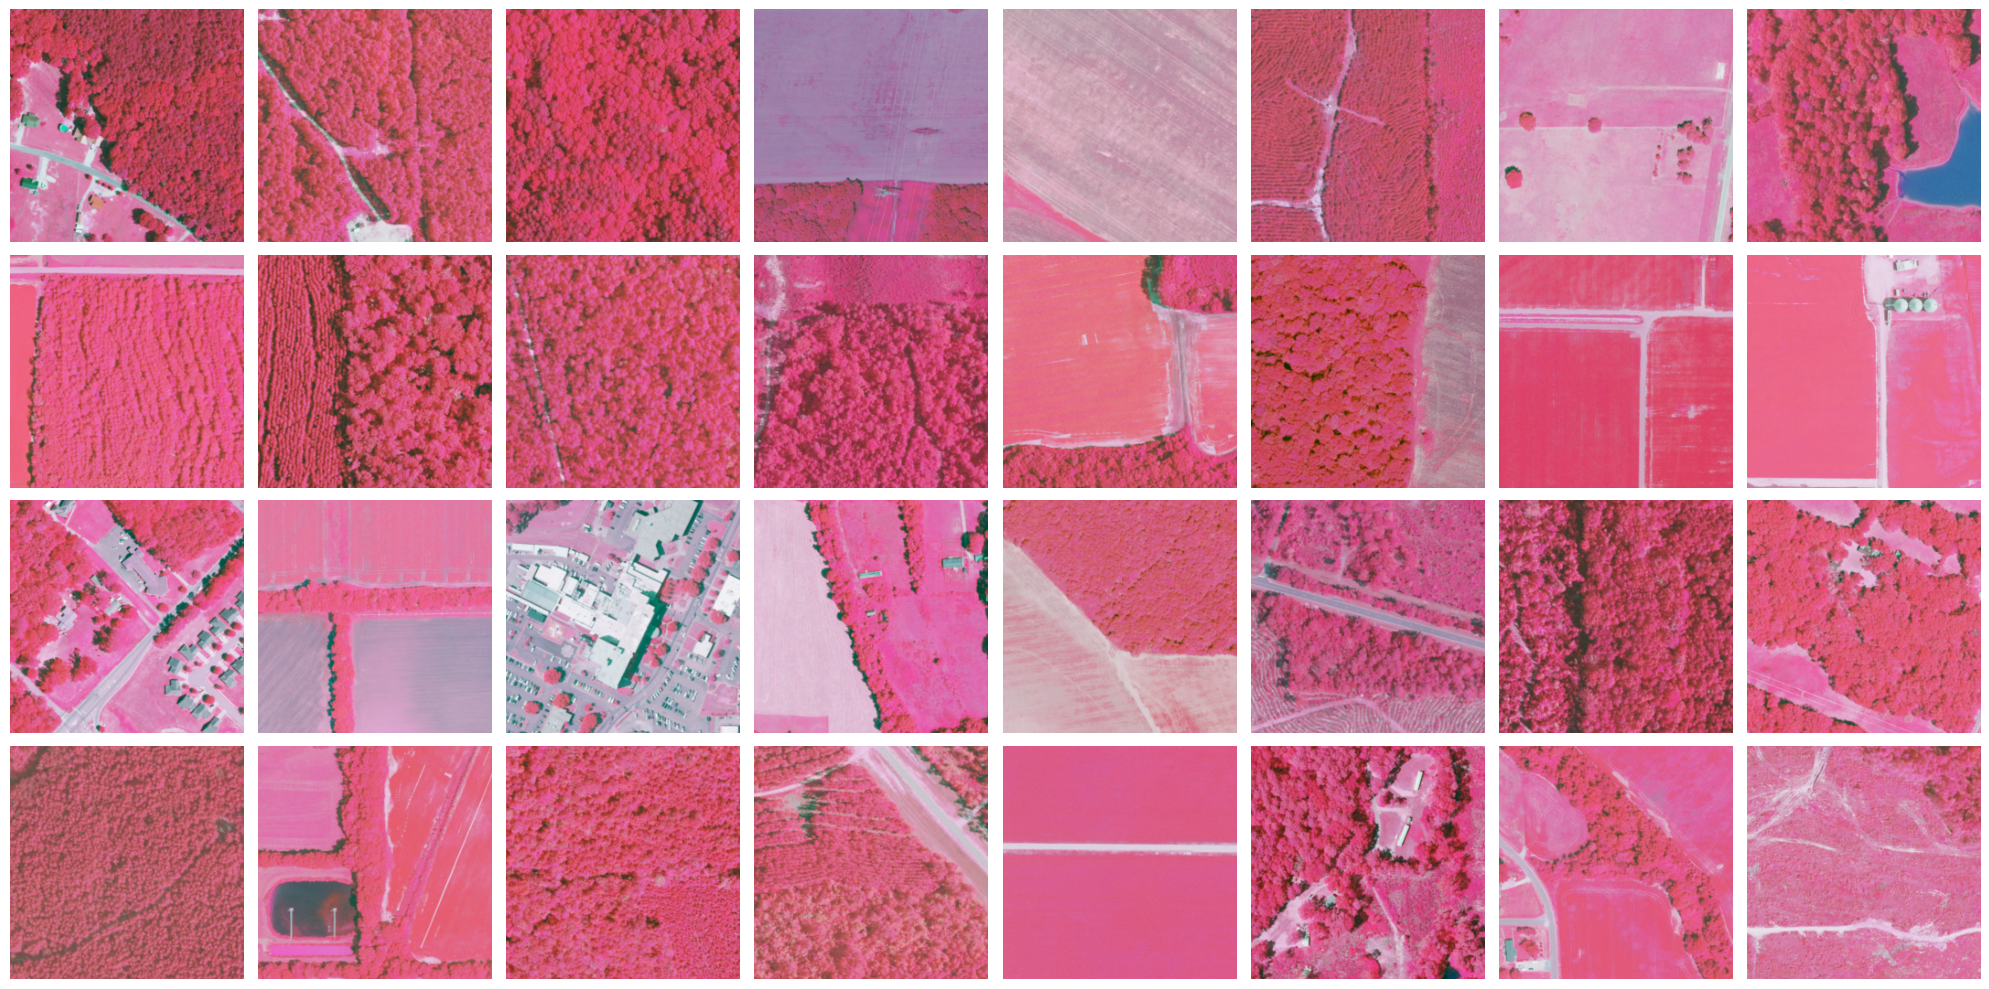

In [ ]:
import rioxarray as rxr
from glob import glob
import matplotlib.pyplot as plt
import os
import numpy as np

pretrain_val_path = '/scratch/dhester/mslc_data_v2/pretrain/'
pretrain_val_files = glob(os.path.join(pretrain_val_path, '*.tif'))

# randomly sample 32 files and plot them
sampled_files = np.random.choice(pretrain_val_files, size=32, replace=False)
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for ax, file in zip(axes.flatten(), sampled_files):
    xa = rxr.open_rasterio(file).to_numpy()
    # select color infrared
    xa = xa[[3, 2, 1], :, :]  # NIR, Red, Green
    img = xa.transpose(1, 2, 0)
    ax.imshow(img)
    # ax.set_title(os.path.basename(file))
    ax.axis('off')
plt.tight_layout()

plt.savefig('../paper/images/sample_pretrain_images.png', dpi=300)
plt.savefig('../paper/images/sample_pretrain_images.pdf', dpi=300)